<a href="https://colab.research.google.com/github/kaytheteenwriter-prog/PROJECT-1/blob/main/PROJECT_1_Leano_Khanyisa_Giyose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

# Load the data
df = pd.read_csv('CSEdata.csv')

# Inspect the data
print(df.head())
print(df.info())
print(df.describe())

   Id   Income  Age  Experience Married/Single House_Ownership Car_Ownership  \
0   1  1303834   23           3         single          rented            no   
1   2  7574516   40          10         single          rented            no   
2   3  3991815   66           4        married          rented            no   
3   4  6256451   41           2         single          rented           yes   
4   5  5768871   47          11         single          rented            no   

            Profession                 CITY           STATE  CURRENT_JOB_YRS  \
0  Mechanical_engineer                 Rewa  Madhya_Pradesh                3   
1   Software_Developer             Parbhani     Maharashtra                9   
2     Technical_writer            Alappuzha          Kerala                4   
3   Software_Developer          Bhubaneswar          Odisha                2   
4        Civil_servant  Tiruchirappalli[10]      Tamil_Nadu                3   

   CURRENT_HOUSE_YRS  Risk_Flag  
0   

--- PERFORMANCE EVALUATION ---
Accuracy: 0.8759
ROC-AUC Score: 0.5000

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93     44147
           1       0.00      0.00      0.00      6253

    accuracy                           0.88     50400
   macro avg       0.44      0.50      0.47     50400
weighted avg       0.77      0.88      0.82     50400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


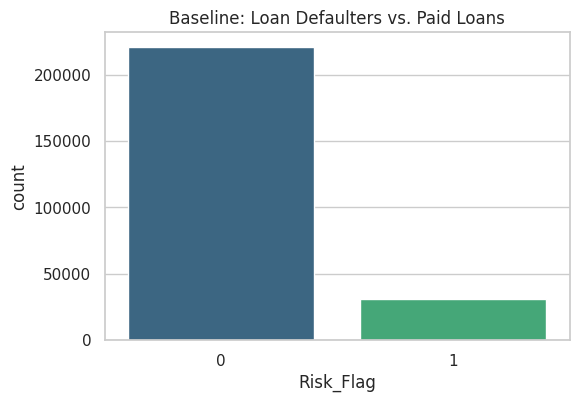

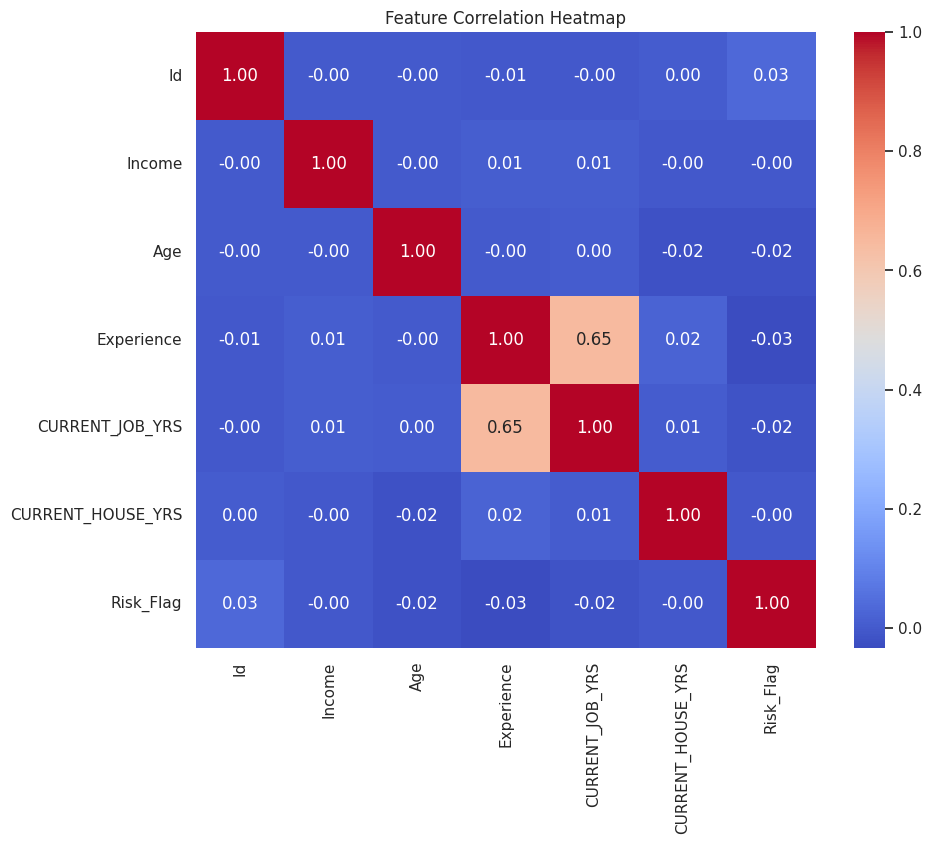

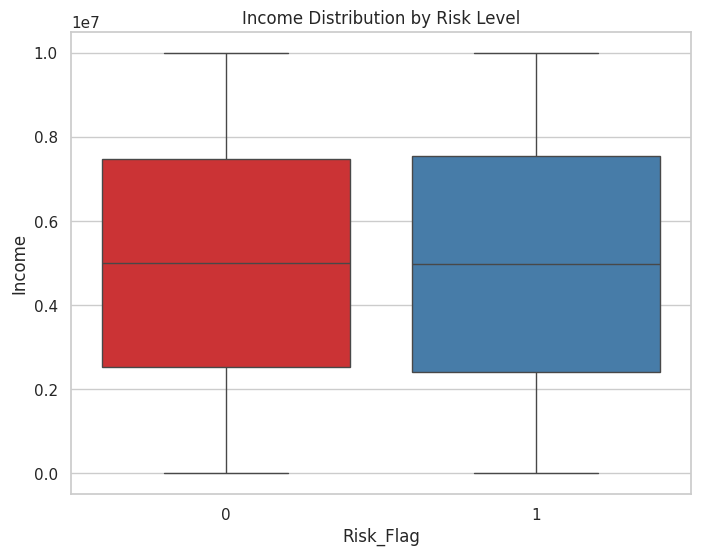

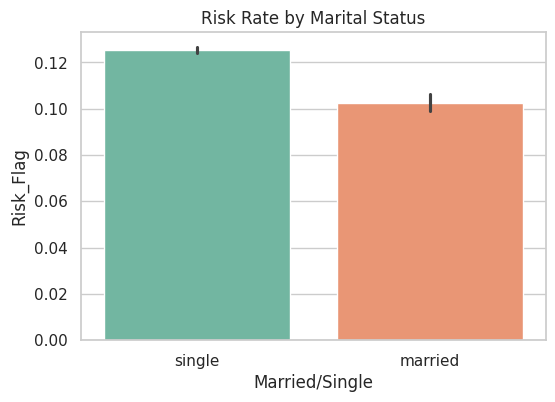

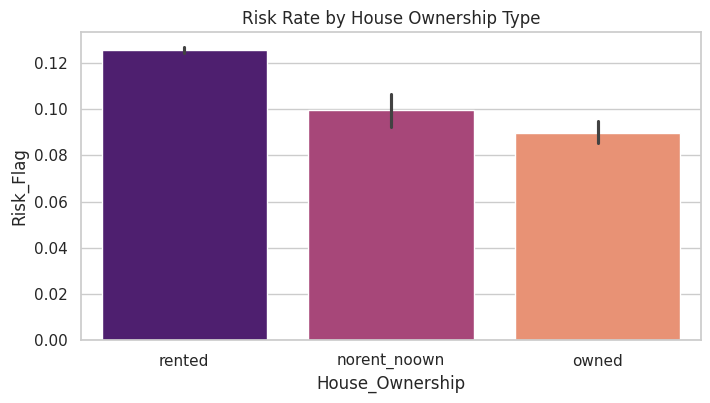

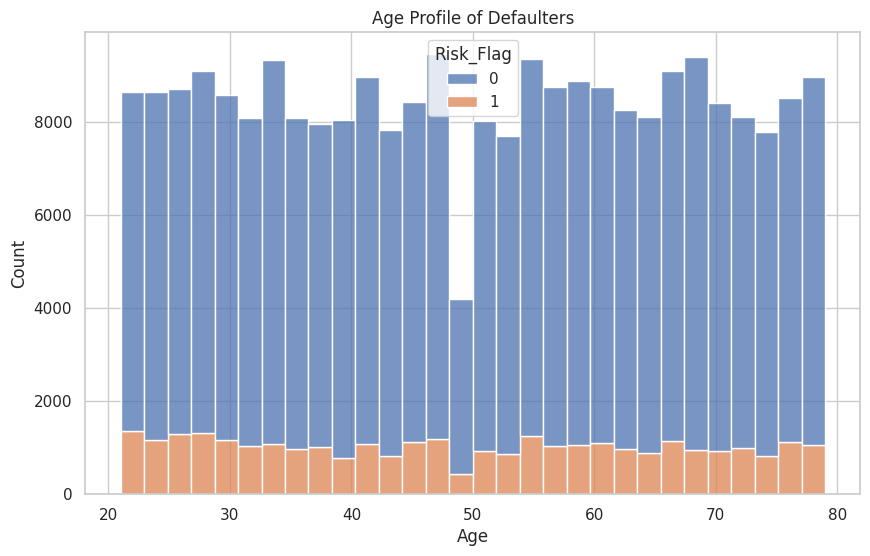

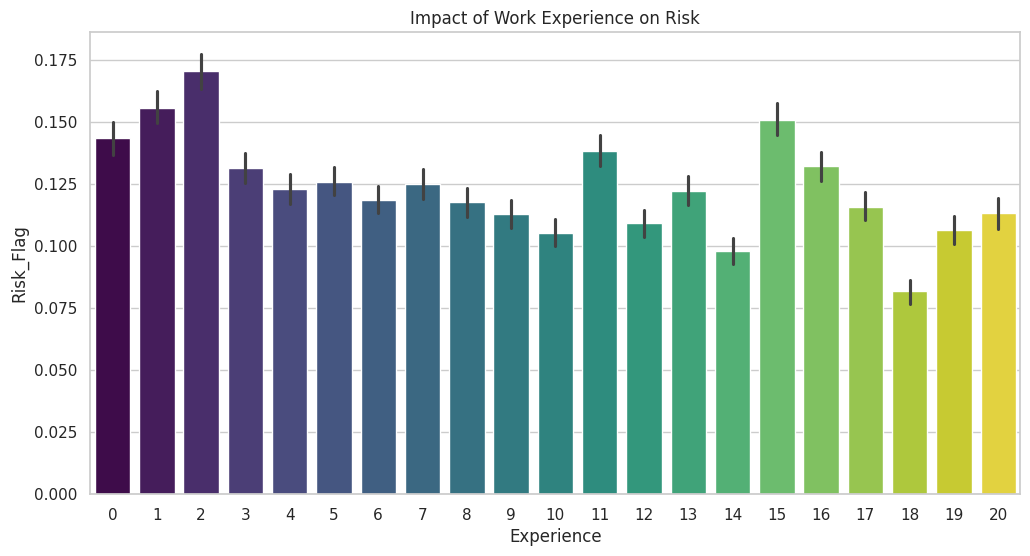

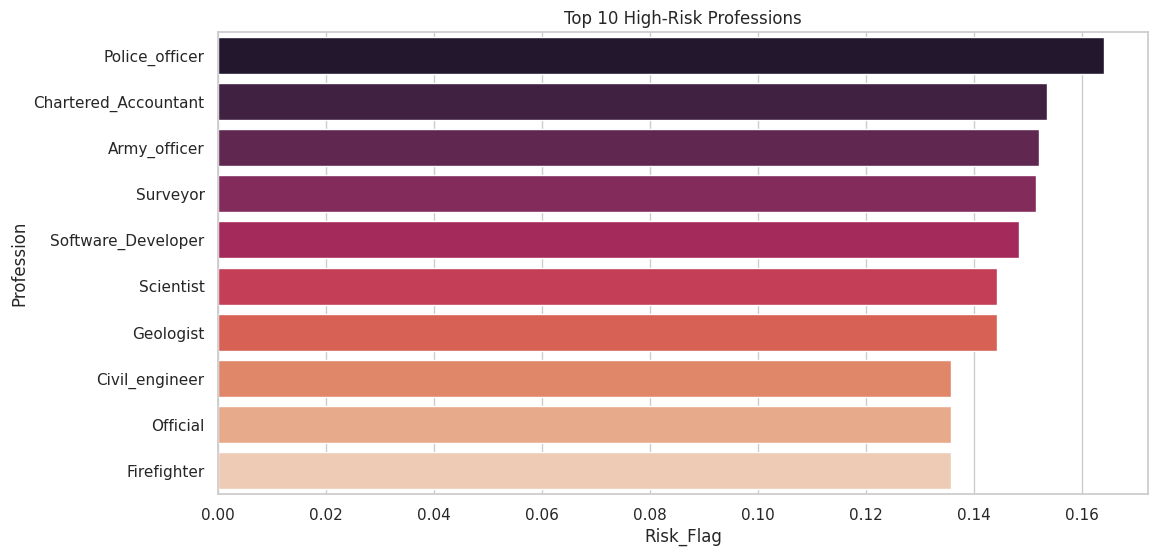

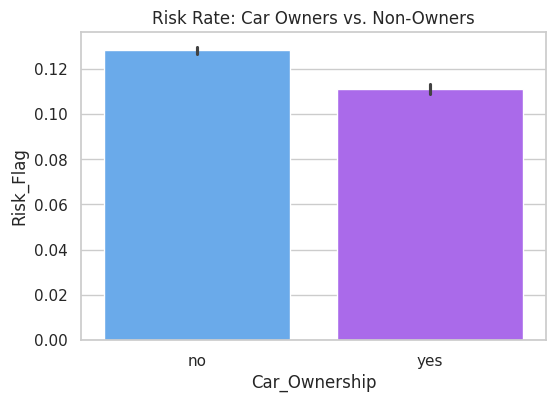

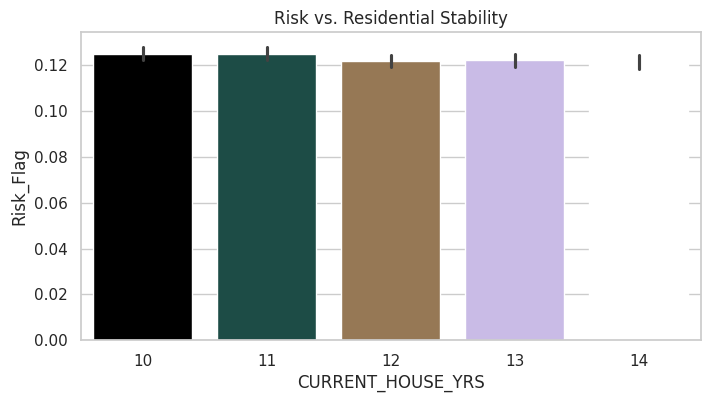

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Load the dataset
df = pd.read_csv('CSEdata.csv')
sns.set_theme(style="whitegrid")

# --- TASK 1: 10 DIAGRAMS (Updated to avoid FutureWarnings) ---

# 1. Distribution of Risk (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Risk_Flag', hue='Risk_Flag', palette='viridis', legend=False)
plt.title('Baseline: Loan Defaulters vs. Paid Loans')
plt.savefig('plot_1_risk.png')

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.savefig('plot_2_heatmap.png')

# 3. Income vs Risk (Box Plot)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Risk_Flag', y='Income', hue='Risk_Flag', palette='Set1', legend=False)
plt.title('Income Distribution by Risk Level')
plt.savefig('plot_3_income.png')

# 4. Marital Status Risk Rate
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Married/Single', y='Risk_Flag', hue='Married/Single', palette='Set2', legend=False)
plt.title('Risk Rate by Marital Status')
plt.savefig('plot_4_marital.png')

# 5. House Ownership Impact
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='House_Ownership', y='Risk_Flag', hue='House_Ownership', palette='magma', legend=False)
plt.title('Risk Rate by House Ownership Type')
plt.savefig('plot_5_house.png')

# 6. Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Risk_Flag', multiple='stack', bins=30)
plt.title('Age Profile of Defaulters')
plt.savefig('plot_6_age.png')

# 7. Experience vs Risk
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Experience', y='Risk_Flag', hue='Experience', palette='viridis', legend=False)
plt.title('Impact of Work Experience on Risk')
plt.savefig('plot_7_experience.png')

# 8. High-Risk Professions (Top 10)
top_prof = df.groupby('Profession')['Risk_Flag'].mean().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_prof, y='Profession', x='Risk_Flag', hue='Profession', palette='rocket', legend=False)
plt.title('Top 10 High-Risk Professions')
plt.savefig('plot_8_profession.png')

# 9. Car Ownership vs Risk
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Car_Ownership', y='Risk_Flag', hue='Car_Ownership', palette='cool', legend=False)
plt.title('Risk Rate: Car Owners vs. Non-Owners')
plt.savefig('plot_9_car.png')

# 10. Stability: Years in House
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='CURRENT_HOUSE_YRS', y='Risk_Flag', hue='CURRENT_HOUSE_YRS', palette='cubehelix', legend=False)
plt.title('Risk vs. Residential Stability')
plt.savefig('plot_10_stability.png')

# --- TASK 2: DATA CLEANING & CURATION ---

# Dropping 'Id' (unique identifier) and 'CITY' (too many categories for logistic regression)
df_ml = df.drop(['Id', 'CITY'], axis=1)

# Categorical Encoding
le = LabelEncoder()
for col in ['Married/Single', 'Car_Ownership', 'House_Ownership', 'Profession', 'STATE']:
    df_ml[col] = le.fit_transform(df_ml[col])

# Feature Scaling (Crucial for Logistic Regression)
scaler = StandardScaler()
num_features = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']
df_ml[num_features] = scaler.fit_transform(df_ml[num_features])

# --- TASK 3: LOGISTIC REGRESSION ---

X = df_ml.drop('Risk_Flag', axis=1)
y = df_ml['Risk_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# --- TASK 4: EVALUATION ---

predictions = log_model.predict(X_test)

print("--- PERFORMANCE EVALUATION ---")
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, predictions):.4f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the raw dataset
df = pd.read_csv('/content/CSEdata.csv')

# 1. Identify and remove unnecessary features
# 'Id' is a unique identifier and adds no predictive value.
# 'CITY' has 317 unique values; keeping it would introduce excessive noise.
df_cleaned = df.drop(columns=['Id', 'CITY'])

# 2. Check for missing values and duplicates
# (Already verified: 0 missing values, 0 duplicate rows)
df_cleaned = df_cleaned.drop_duplicates()

# 3. Categorical Encoding
# Logistic Regression requires numeric input. We use LabelEncoder to
# transform text-based categories into numbers.
le = LabelEncoder()
categorical_cols = ['Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'STATE']

for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

# 4. Feature Scaling
# Since 'Income' is in the millions and 'Age' is in the tens, we scale
# the data to ensure the model doesn't over-prioritize large numbers.
scaler = StandardScaler()
numerical_cols = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']
df_cleaned[numerical_cols] = scaler.fit_transform(df_cleaned[numerical_cols])

# Save the finalized dataset for Task 3
df_cleaned.to_csv('cleaned_loan_data.csv', index=False)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Load the cleaned data
df = pd.read_csv('cleaned_loan_data.csv')

# Define Features (X) and Target (y)
X = df.drop('Risk_Flag', axis=1)
y = df['Risk_Flag']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
# We set max_iter=1000 to ensure the mathematical solver converges
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Generate predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Calculate Performance Metrics
print("--- PERFORMANCE EVALUATION ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- PERFORMANCE EVALUATION ---
Accuracy: 0.8083
ROC-AUC Score: 0.4949

Confusion Matrix:
 [[6982    0]
 [1656    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.89      6982
           1       0.00      0.00      0.00      1656

    accuracy                           0.81      8638
   macro avg       0.40      0.50      0.45      8638
weighted avg       0.65      0.81      0.72      8638



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
